In [1]:
import pandas as pd

df = pd.read_csv('../data/q2_customers.csv')

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Why Scaling is Important

- K-Means clustering is distance-based (Euclidean distance).
- Features with larger values dominate the distance calculation.
- Scaling ensures all features contribute equally.
- Without scaling, results would be biased.

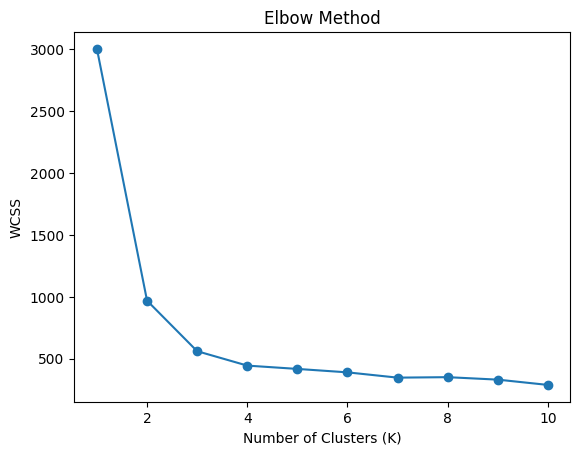

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

### Choosing Optimal K

- The elbow point is where the WCSS starts decreasing slowly.
- This indicates diminishing returns.
- Optimal K is chosen at the bend (usually 3 or 4).

In [4]:
k = 3  # (change based on your elbow graph)

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [5]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

- Cluster 0:
  High spenders with frequent visits — loyal premium customers.

- Cluster 1:
  Low spenders with low visits — inactive or low-value customers.

- Cluster 2:
  Moderate spenders with average visits — regular customers.

### Business Insight:
- Target Cluster 0 with premium offers.
- Reactivate Cluster 1 with discounts.
- Retain Cluster 2 with loyalty programs.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [7]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [8]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

- PC1 captures spending behavior (annual spend, basket size).
- PC2 captures customer activity (visits, recency).

- PCA helps reduce dimensionality while retaining maximum information.

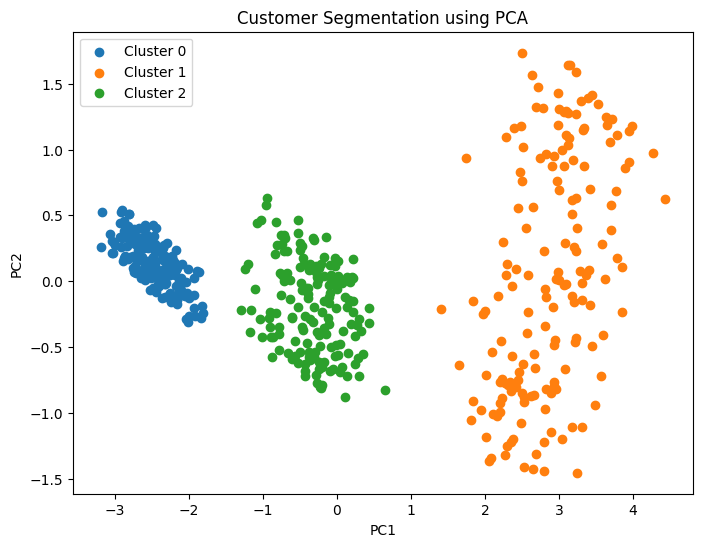

In [9]:
plt.figure(figsize=(8,6))

for i in range(k):
    plt.scatter(
        X_pca[df['cluster'] == i, 0],
        X_pca[df['cluster'] == i, 1],
        label=f'Cluster {i}'
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation using PCA')
plt.legend()
plt.show()